In [2]:
#from pathlib import Path

#from intrarepresentational_alignment.data import load_metanet

In [3]:
#DATA_PATH = Path("data/mr-en-20250924142102.rdf")

In [4]:
#repo = load_metanet(DATA_PATH)
#print(f"Loaded  {len(repo.metaphors):,} metaphors, {len(repo.frames):,} frames, "
#      f"{len(repo.mappings):,} mappings, {len(repo.examples):,} examples")

## LCC Metaphor Corpus â€” Source & Target Domain Kernel Matrices

In [5]:
from collections import Counter
from pathlib import Path

from intrarepresentational_alignment.data import load_lcc

LCC_PATH = Path("data/en_small.xml")
instances = load_lcc(LCC_PATH)
print(f"Loaded {len(instances):,} LCC instances")

annotated = [i for i in instances if i.source_concept and i.source_concept != "OTHER"]
print(f"With explicit source concept (excl. OTHER): {len(annotated):,}")

pair_counts = Counter(
    (inst.source_concept, inst.target_concept)
    for inst in annotated
)
print(f"\nTop 15 (source domain â†’ target domain) pairs:")
for (src, tgt), n in pair_counts.most_common(15):
    print(f"  {src:<30} â†’ {tgt:<25} (n={n})")

Loaded 16,265 LCC instances
With explicit source concept (excl. OTHER): 3,336

Top 15 (source domain â†’ target domain) pairs:
  DISEASE                        â†’ POVERTY                   (n=43)
  PROTECTION                     â†’ GUN_RIGHTS                (n=34)
  ABYSS                          â†’ POVERTY                   (n=22)
  PHYSICAL_LOCATION              â†’ POVERTY                   (n=22)
  PROTECTION                     â†’ GUNS                      (n=19)
  STRUGGLE                       â†’ POVERTY                   (n=18)
  PROTECTION                     â†’ DEMOCRACY                 (n=18)
  MOVEMENT                       â†’ CONTROL_OF_GUNS           (n=18)
  PHYSICAL_BURDEN                â†’ TAXATION                  (n=17)
  MOVEMENT                       â†’ GOVERNMENT                (n=17)
  MOVEMENT                       â†’ GUNS                      (n=16)
  ANIMAL                         â†’ GUNS                      (n=15)
  MOVEMENT                       

## Per-domain CKA experiments

In [6]:
from collections import defaultdict
import numpy as np

from intrarepresentational_alignment.alignment import cka_permutation_test, PermutationTestResult
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.models import EmbeddingModel

MIN_PAIRS = 8
MAX_PAIRS = 30
N_PERMS   = 500

embedder = Embedder(EmbeddingModel.ALL_MINILM_L6_V2)

# Group (source_expr, target_expr) pairs by (source_concept, target_concept)
domain_pairs: dict[tuple, list[tuple]] = defaultdict(list)
for inst in annotated:
    for s in inst.source_expressions:
        for t in inst.target_expressions:
            domain_pairs[(inst.source_concept, inst.target_concept)].append((s, t))

# Keep only domains whose pair count falls in [MIN_PAIRS, MAX_PAIRS]
selected = sorted(
    [k for k in domain_pairs if MIN_PAIRS <= len(domain_pairs[k]) <= MAX_PAIRS],
    key=lambda k: len(domain_pairs[k]), reverse=True,
)
print(f'Domains with {MIN_PAIRS}-{MAX_PAIRS} pairs: {len(selected)}')

domain_results: dict[tuple, PermutationTestResult] = {}
domain_n: dict[tuple, int] = {}

print(f"{'Source domain':<28} {'Target domain':<22} {'n':>4}  {'CKA':>6}  {'p':>6}")
print("-" * 70)

for key in selected:
    src_concept, tgt_concept = key
    pairs  = domain_pairs[key]
    src    = [s for s, _ in pairs]
    tgt    = [t for _, t in pairs]

    S = embedder.embed(src)
    T = embedder.embed(tgt)

    result = cka_permutation_test(
        S @ S.T, T @ T.T,
        n_permutations=N_PERMS,
        rng=np.random.default_rng(42),
    )
    domain_results[key] = result
    domain_n[key]       = len(pairs)

    sig = " *" if result.p_value < 0.05 else ""
    print(f"{src_concept:<28} {tgt_concept:<22} {len(pairs):>4}  "
          f"{result.observed:>6.3f}  {result.p_value:>6.3f}{sig}")


c:\Users\afjal\ICL Code\Intra\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6438.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Domains with 8-30 pairs: 75
Source domain                Target domain             n     CKA       p
----------------------------------------------------------------------
ABYSS                        POVERTY                  22   0.311   0.010 *
PHYSICAL_LOCATION            POVERTY                  22   0.044   1.000
PROTECTION                   GUNS                     19   0.358   0.014 *
STRUGGLE                     POVERTY                  18   0.262   0.926
PROTECTION                   DEMOCRACY                18   0.386   0.052
MOVEMENT                     CONTROL_OF_GUNS          18   0.253   0.204
PHYSICAL_BURDEN              TAXATION                 17   0.139   0.564
MOVEMENT                     GOVERNMENT               17   0.460   0.068
MOVEMENT                     GUNS                     16   0.278   0.958
ANIMAL                       GUNS                     15   0.473   0.754
MOVEMENT                     DEMOCRACY                14   0.400   0.196
BUILDING             

c:\Users\afjal\ICL Code\Intra\intrarepresentational-alignment\intrarepresentational_alignment\alignment.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return float(hsic_kl / np.sqrt(hsic_kk * hsic_ll))


UPWARD_MOVEMENT              POVERTY                   8   0.258   0.734
STRUGGLE                     ELECTIONS                 8   0.669   0.754
TOOL                         GUNS                      8   0.334   0.406
OBJECT_HANDLING              GUNS                      8   0.572   0.160
BUILDING                     CONTROL_OF_GUNS           8   0.405   0.850
LEADER                       BUREAUCRACY               8   0.503   0.658
GAME                         GUN_RIGHTS                8   0.740   0.698
DISEASE                      GUN_VIOLENCE              8   0.270   0.630


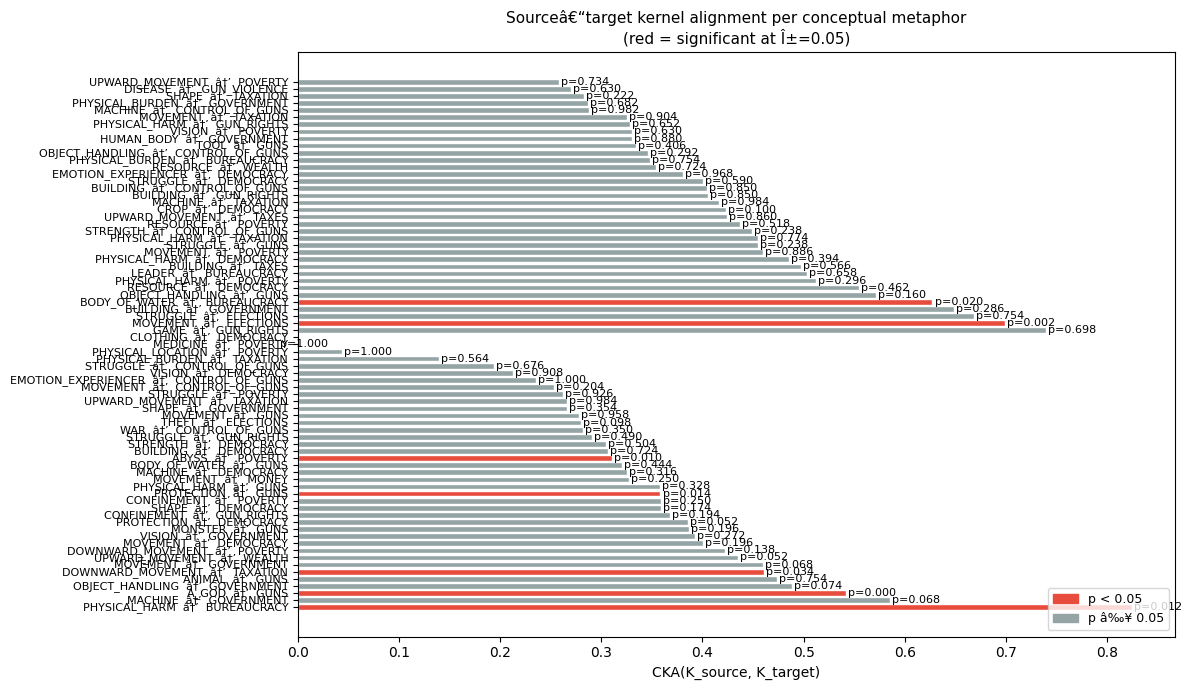

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sorted_keys = sorted(domain_results, key=lambda k: domain_results[k].observed, reverse=True)
cka_scores  = [domain_results[k].observed for k in sorted_keys]
p_values    = [domain_results[k].p_value  for k in sorted_keys]
labels      = [f"{s}  â†’  {t}" for s, t in sorted_keys]
colors      = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in p_values]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(sorted_keys)), cka_scores, color=colors, edgecolor="white")

for i, (score, p) in enumerate(zip(cka_scores, p_values)):
    ax.text(score + 0.002, i, f"p={p:.3f}", va="center", fontsize=8)

ax.set_yticks(range(len(sorted_keys)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("CKA(K_source, K_target)", fontsize=10)
ax.set_title("Sourceâ€“target kernel alignment per conceptual metaphor\n"
             "(red = significant at Î±=0.05)", fontsize=11)
ax.set_xlim(left=0)
ax.legend(handles=[
    mpatches.Patch(color="#e74c3c", label="p < 0.05"),
    mpatches.Patch(color="#95a5a6", label="p â‰¥ 0.05"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

### Graph Edit Distance alignment

In [8]:
import numpy as np
from intrarepresentational_alignment.alignment import ged_permutation_test, PermutationTestResult

ged_results: dict[tuple, PermutationTestResult] = {}

print(f"{'Source domain':<28} {'Target domain':<22} {'CKA':>6}  {'GED':>6}  {'p(CKA)':>7}  {'p(GED)':>7}")
print("-" * 82)

for key in selected:
    src_concept, tgt_concept = key
    pairs = domain_pairs[key]
    src   = [s for s, _ in pairs]
    tgt   = [t for _, t in pairs]

    S = embedder.embed(src)
    T = embedder.embed(tgt)
    K_S, K_T = S @ S.T, T @ T.T

    ged_result = ged_permutation_test(
        K_S, K_T,
        n_permutations=N_PERMS,
        rng=np.random.default_rng(42),
    )
    ged_results[key] = ged_result

    cka_r = domain_results[key]
    sig_c = "*" if cka_r.p_value   < 0.05 else " "
    sig_g = "*" if ged_result.p_value < 0.05 else " "
    print(f"{src_concept:<28} {tgt_concept:<22} "
          f"{cka_r.observed:>6.3f}  {ged_result.observed:>6.3f}  "
          f"{cka_r.p_value:>6.3f}{sig_c}  {ged_result.p_value:>6.3f}{sig_g}")

Source domain                Target domain             CKA     GED   p(CKA)   p(GED)
----------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.311   0.428   0.010*   0.968 
PHYSICAL_LOCATION            POVERTY                 0.044   0.198   1.000    1.000 
PROTECTION                   GUNS                    0.358   0.249   0.014*   0.008*
STRUGGLE                     POVERTY                 0.262   0.354   0.926    0.990 
PROTECTION                   DEMOCRACY               0.386   0.301   0.052    0.972 
MOVEMENT                     CONTROL_OF_GUNS         0.253   0.326   0.204    0.230 
PHYSICAL_BURDEN              TAXATION                0.139   0.226   0.564    0.648 
MOVEMENT                     GOVERNMENT              0.460   0.437   0.068    0.046*
MOVEMENT                     GUNS                    0.278   0.501   0.958    0.944 
ANIMAL                       GUNS                    0.473   0.475 

In [9]:
# Summary table: significant results (p < 0.05 on CKA or GED)
interesting = [
    key for key in selected
    if domain_results[key].p_value < 0.05 or ged_results[key].p_value < 0.05
]

# Sort by CKA (descending)
interesting.sort(key=lambda k: domain_results[k].observed, reverse=True)

header = f"{'Source domain':<22}  {'Target domain':<22}  {'n':>4}  {'CKA':>6}  {'p(CKA)':>7}  {'GED':>6}  {'p(GED)':>7}"
sep    = "-" * len(header)
print(header)
print(sep)
for key in interesting:
    src, tgt = key
    n     = domain_n[key]
    cka_r = domain_results[key]
    ged_r = ged_results[key]
    sig_c = "*" if cka_r.p_value   < 0.05 else " "
    sig_g = "*" if ged_r.p_value   < 0.05 else " "
    print(f"{src:<22}  {tgt:<22}  {n:>4}  "
          f"{cka_r.observed:>6.3f}  {cka_r.p_value:>6.3f}{sig_c}  "
          f"{ged_r.observed:>6.3f}  {ged_r.p_value:>6.3f}{sig_g}")
print(sep)
print(f"  {len(interesting)} of {len(selected)} domain pairs significant at p < 0.05")


Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)
--------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                8   0.825   0.012*   0.194   0.008*
MOVEMENT                ELECTIONS                  9   0.699   0.002*   0.419   0.026*
BODY_OF_WATER           BUREAUCRACY                9   0.627   0.020*   0.294   0.128 
A_GOD                   GUNS                      11   0.542   0.000*   0.376   0.034*
DOWNWARD_MOVEMENT       TAXATION                  13   0.461   0.034*   0.291   0.048*
MOVEMENT                GOVERNMENT                17   0.460   0.068    0.437   0.046*
PROTECTION              GUNS                      19   0.358   0.014*   0.249   0.008*
ABYSS                   POVERTY                   22   0.311   0.010*   0.428   0.968 
CLOTHING                DEMOCRACY                  8     nan   0.000*   0.442   1.000 
OBJECT_HANDLING         GUNS               

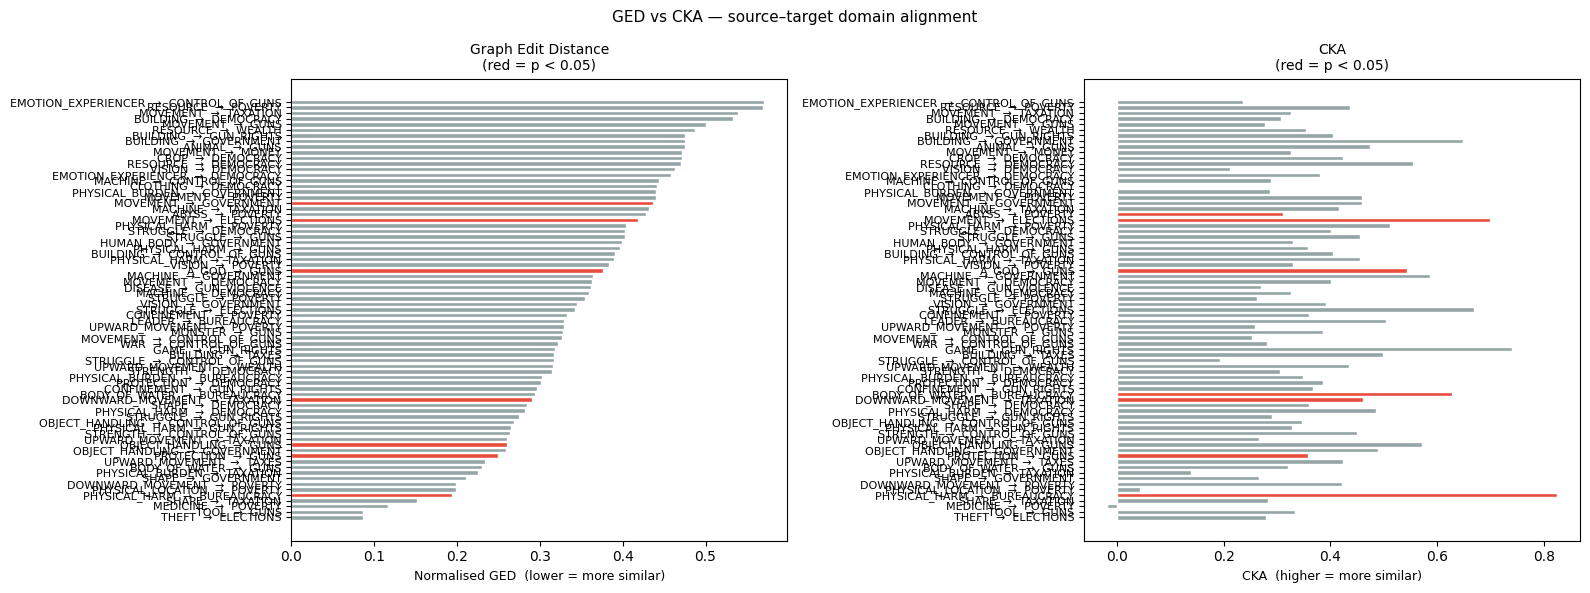

In [10]:
import matplotlib.pyplot as plt
import numpy as np

sorted_keys = sorted(ged_results, key=lambda k: ged_results[k].observed)
ged_scores  = [ged_results[k].observed     for k in sorted_keys]
cka_scores  = [domain_results[k].observed  for k in sorted_keys]
ged_p       = [ged_results[k].p_value      for k in sorted_keys]
labels      = [f"{s}  →  {t}" for s, t in sorted_keys]

y, h = np.arange(len(sorted_keys)), 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GED (lower = more similar)
colors_ged = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in ged_p]
axes[0].barh(y, ged_scores, color=colors_ged, edgecolor="white")
axes[0].set_yticks(y)
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_xlabel("Normalised GED  (lower = more similar)", fontsize=9)
axes[0].set_title("Graph Edit Distance\n(red = p < 0.05)", fontsize=10)

# CKA (higher = more similar)
colors_cka = ["#e74c3c" if domain_results[k].p_value < 0.05 else "#95a5a6" for k in sorted_keys]
axes[1].barh(y, cka_scores, color=colors_cka, edgecolor="white")
axes[1].set_yticks(y)
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel("CKA  (higher = more similar)", fontsize=9)
axes[1].set_title("CKA\n(red = p < 0.05)", fontsize=10)

fig.suptitle("GED vs CKA — source–target domain alignment", fontsize=11)
plt.tight_layout()
plt.show()

### Sparse kernel (TopFraction 20%) — re-run experiments

In [11]:
import numpy as np

from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.alignment import cka_permutation_test, PermutationTestResult

EDGE_FRACTION = 0.20
sparse_metric  = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))
sparse_results: dict[tuple, PermutationTestResult] = {}

print(f"{'Source domain':<28} {'Target domain':<22} {'CKA(dense)':>10}  {'CKA(sparse)':>11}  {'p(dense)':>8}  {'p(sparse)':>9}")
print("-" * 96)

for key in selected:
    src_concept, tgt_concept = key
    pairs = domain_pairs[key]
    src   = [s for s, _ in pairs]
    tgt   = [t for _, t in pairs]

    S = embedder.embed(src)
    T = embedder.embed(tgt)

    result = cka_permutation_test(
        sparse_metric.matrix(S), sparse_metric.matrix(T),
        n_permutations=N_PERMS,
        rng=np.random.default_rng(42),
    )
    sparse_results[key] = result

    dense = domain_results[key]
    sig_d = " *" if dense.p_value  < 0.05 else "  "
    sig_s = " *" if result.p_value < 0.05 else "  "
    print(f"{src_concept:<28} {tgt_concept:<22} "
          f"{dense.observed:>10.3f}  {result.observed:>11.3f}  "
          f"{dense.p_value:>8.3f}{sig_d}  {result.p_value:>9.3f}{sig_s}")

Source domain                Target domain          CKA(dense)  CKA(sparse)  p(dense)  p(sparse)
------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                     0.311        0.156     0.010 *      0.030 *
PHYSICAL_LOCATION            POVERTY                     0.044        0.022     1.000        0.414  
PROTECTION                   GUNS                        0.358        0.073     0.014 *      0.192  
STRUGGLE                     POVERTY                     0.262        0.110     0.926        0.144  
PROTECTION                   DEMOCRACY                   0.386        0.031     0.052        0.378  
MOVEMENT                     CONTROL_OF_GUNS             0.253        0.035     0.204        0.430  
PHYSICAL_BURDEN              TAXATION                    0.139        0.130     0.564        0.102  
MOVEMENT                     GOVERNMENT                  0.460       -0.047     0.068        0.768 

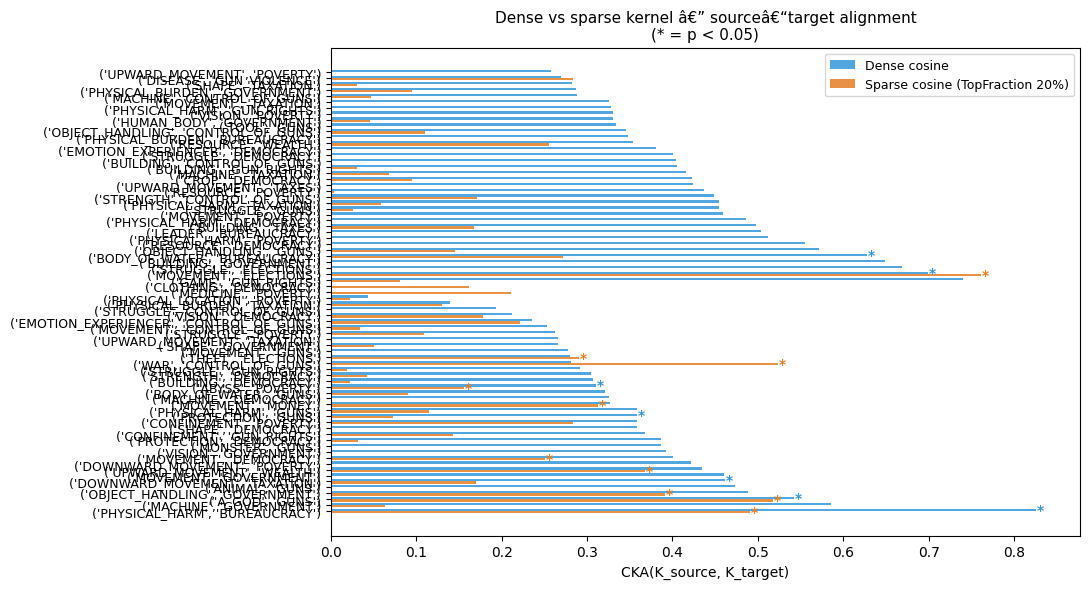

In [12]:
import matplotlib.pyplot as plt
import numpy as np

shared_sorted = sorted(domain_results, key=lambda d: domain_results[d].observed, reverse=True)

dense_scores  = [domain_results[d].observed for d in shared_sorted]
sparse_scores = [sparse_results[d].observed for d in shared_sorted]
dense_p       = [domain_results[d].p_value  for d in shared_sorted]
sparse_p      = [sparse_results[d].p_value  for d in shared_sorted]

y, h = np.arange(len(shared_sorted)), 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y + h/2, dense_scores,  h, color="#3498db", alpha=0.85, label="Dense cosine")
ax.barh(y - h/2, sparse_scores, h, color="#e67e22", alpha=0.85, label=f"Sparse cosine (TopFraction {int(EDGE_FRACTION*100)}%)")

for i, (ds, ss, dp, sp) in enumerate(zip(dense_scores, sparse_scores, dense_p, sparse_p)):
    if dp < 0.05:
        ax.text(ds + 0.001, i + h/2, "*", va="center", color="#3498db", fontweight="bold")
    if sp < 0.05:
        ax.text(ss + 0.001, i - h/2, "*", va="center", color="#e67e22", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(shared_sorted, fontsize=9)
ax.set_xlabel("CKA(K_source, K_target)", fontsize=10)
ax.set_title(f"Dense vs sparse kernel â€” sourceâ€“target alignment\n(* = p < 0.05)", fontsize=11)
ax.set_xlim(left=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()